In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
candidates = [
  Path("/content/canonical_dataset.csv"),
  Path("/content/runs/canonical_dataset.csv"),
  Path("/content/drive/MyDrive/Fairness Ops/runs/canonical_dataset.csv"),
  Path("/content/drive/MyDrive/canonical_dataset.csv"),
]
DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
  raise FileNotFoundError(
      "canonical_dataset.csv not found. Update DATA_PATH to your actual file location."
  )

In [4]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

In [5]:
candidates = [
  Path("/content/canonical_dataset.csv"),
  Path("/content/runs/canonical_dataset.csv"),
  Path("/content/drive/MyDrive/Fairness Ops/runs/canonical_dataset.csv"),
  Path("/content/drive/MyDrive/canonical_dataset.csv"),
]
DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
  raise FileNotFoundError(
      "canonical_dataset.csv not found. Update DATA_PATH to your actual file location."
  )
print("Using:", DATA_PATH)

Using: /content/canonical_dataset.csv


In [8]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head(5))
# ----------------------------
# 3) Basic schema + missingness
# ----------------------------
print("\nDtypes:")
display(df.dtypes.to_frame("dtype").T)
missing_pct = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
print("\nMissingness (%):")
display(missing_pct.to_frame("missing_pct"))
# ----------------------------
# 4) Label distribution
# ----------------------------
if "y_true" not in df.columns:
  raise ValueError("Expected column 'y_true' not found.")
label_counts = df["y_true"].value_counts(dropna=False).sort_index()
label_pct = (df["y_true"].value_counts(normalize=True, dropna=False) * 100).sort_index().round(2)
print("\nLabel counts:")
display(label_counts.to_frame("count"))
print("Label percent:")
display(label_pct.to_frame("pct"))
print(f"Mortality prevalence (y_true=1): {df['y_true'].mean():.3%}")


Shape: (2520, 17)


,patientunitstayid,hospitalid,y_true,ethnicity,gender,age_group,insurance,language,region,lab_creatinine,lab_sodium,lab_glucose,lab_potassium,vital_heartrate,vital_sao2,vital_respiration,apachescore
0,141764,59,0,Caucasian,Female,over_65,Unknown,Unknown,Midwest,NaN,NaN,NaN,NaN,104.0,NaN,NaN,NaN
1,141765,59,0,Caucasian,Female,over_65,Unknown,Unknown,Midwest,1.040,139.0,79.0,4.10,86.0,97.0,24.0,47.0
2,143870,68,0,Caucasian,Male,over_65,Unknown,Unknown,Midwest,1.015,136.0,131.5,4.40,46.0,96.0,67.0,60.0
3,144815,56,0,Caucasian,Female,under_45,Unknown,Unknown,Midwest,0.690,141.0,90.5,3.75,82.0,99.0,17.0,25.0
4,145427,68,0,Caucasian,Male,45_65,Unknown,Unknown,Midwest,1.120,139.5,128.5,4.35,64.0,96.0,16.0,37.0



Dtypes:


,patientunitstayid,hospitalid,y_true,ethnicity,gender,age_group,insurance,language,region,lab_creatinine,lab_sodium,lab_glucose,lab_potassium,vital_heartrate,vital_sao2,vital_respiration,apachescore
dtype,int64,int64,int64,object,object,object,object,object,object,float64,float64,float64,float64,float64,float64,float64,float64



Missingness (%):


...


Label counts:


,count
y_true,
0,2308
1,212


Label percent:


,pct
y_true,
0,91.59
1,8.41


Mortality prevalence (y_true=1): 8.413%


In [9]:
# ----------------------------
# 5) Protected attribute profiling
# ----------------------------
protected_cols = [c for c in ["ethnicity", "gender", "age_group", "region", "insurance", "language"] if c in df.columns]
for c in protected_cols:
  print(f"\n=== {c} distribution ===")
  vc = df[c].fillna("Unknown").value_counts(dropna=False)
  display(vc.to_frame("count").head(20))


=== ethnicity distribution ===


,count
ethnicity,
Caucasian,2010
African American,231
Hispanic,115
Other/Unknown,83
Unknown,39
Asian,30
Native American,12



=== gender distribution ===


,count
gender,
Male,1508
Female,1008
Unknown,4



=== age_group distribution ===


...

,count
region,
Midwest,807
South,738
West,606
Unknown,210
Northeast,159



=== insurance distribution ===


,count
insurance,
Unknown,2520



=== language distribution ===


,count
language,
Unknown,2520


In [10]:
id_and_label = {"patientunitstayid", "hospitalid", "y_true"}
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in id_and_label]
print("\nNumeric modeling columns:")
print(numeric_cols)
if numeric_cols:
  print("\nSummary stats:")
  display(df[numeric_cols].describe().T)



Numeric modeling columns:
['lab_creatinine', 'lab_sodium', 'lab_glucose', 'lab_potassium', 'vital_heartrate', 'vital_sao2', 'vital_respiration', 'apachescore']

Summary stats:


,count,mean,std,min,25%,50%,75%,max
lab_creatinine,2373.0,1.347679,1.345286,0.2,0.74,0.97,1.34,13.63
lab_sodium,2369.0,138.329358,4.511858,108.0,136.00,138.50,141.00,178.00
lab_glucose,2353.0,138.213132,63.362184,51.0,102.50,119.50,151.00,896.00
lab_potassium,2341.0,4.023778,0.484778,2.0,3.70,4.00,4.25,7.20
vital_heartrate,2364.0,83.136844,16.300480,6.0,71.00,82.00,94.00,151.00
vital_sao2,2330.0,96.664378,3.448327,0.0,95.00,97.00,98.00,100.00
vital_respiration,2162.0,19.331175,4.796598,0.0,16.00,19.00,22.00,67.00
apachescore,1838.0,51.956474,25.253063,-1.0,35.25,48.00,65.00,185.00


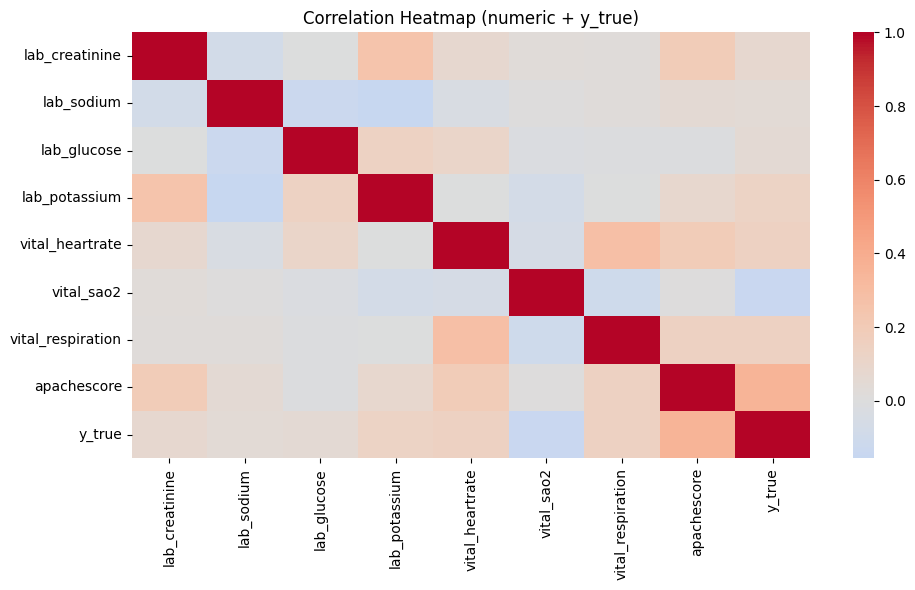

In [11]:
if len(numeric_cols) >= 2:
  plt.figure(figsize=(10, 6))
  corr = df[numeric_cols + ["y_true"]].corr(numeric_only=True)
  sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
  plt.title("Correlation Heatmap (numeric + y_true)")
  plt.tight_layout()
  plt.show()

Using: /content/canonical_dataset.csv
Shape: (2520, 17)


,patientunitstayid,hospitalid,y_true,ethnicity,gender,age_group,insurance,language,region,lab_creatinine,lab_sodium,lab_glucose,lab_potassium,vital_heartrate,vital_sao2,vital_respiration,apachescore
0,141764,59,0,Caucasian,Female,over_65,Unknown,Unknown,Midwest,NaN,NaN,NaN,NaN,104.0,NaN,NaN,NaN
1,141765,59,0,Caucasian,Female,over_65,Unknown,Unknown,Midwest,1.040,139.0,79.0,4.10,86.0,97.0,24.0,47.0
2,143870,68,0,Caucasian,Male,over_65,Unknown,Unknown,Midwest,1.015,136.0,131.5,4.40,46.0,96.0,67.0,60.0
3,144815,56,0,Caucasian,Female,under_45,Unknown,Unknown,Midwest,0.690,141.0,90.5,3.75,82.0,99.0,17.0,25.0
4,145427,68,0,Caucasian,Male,45_65,Unknown,Unknown,Midwest,1.120,139.5,128.5,4.35,64.0,96.0,16.0,37.0



Dtypes:


,patientunitstayid,hospitalid,y_true,ethnicity,gender,age_group,insurance,language,region,lab_creatinine,lab_sodium,lab_glucose,lab_potassium,vital_heartrate,vital_sao2,vital_respiration,apachescore
dtype,int64,int64,int64,object,object,object,object,object,object,float64,float64,float64,float64,float64,float64,float64,float64



Missingness (%):


...

,count
insurance,
Unknown,2520



=== language distribution ===


,count
language,
Unknown,2520



Numeric modeling columns:
['lab_creatinine', 'lab_sodium', 'lab_glucose', 'lab_potassium', 'vital_heartrate', 'vital_sao2', 'vital_respiration', 'apachescore']

Summary stats:


,count,mean,std,min,25%,50%,75%,max
lab_creatinine,2373.0,1.347679,1.345286,0.2,0.74,0.97,1.34,13.63
lab_sodium,2369.0,138.329358,4.511858,108.0,136.00,138.50,141.00,178.00
lab_glucose,2353.0,138.213132,63.362184,51.0,102.50,119.50,151.00,896.00
lab_potassium,2341.0,4.023778,0.484778,2.0,3.70,4.00,4.25,7.20
vital_heartrate,2364.0,83.136844,16.300480,6.0,71.00,82.00,94.00,151.00
vital_sao2,2330.0,96.664378,3.448327,0.0,95.00,97.00,98.00,100.00
vital_respiration,2162.0,19.331175,4.796598,0.0,16.00,19.00,22.00,67.00
apachescore,1838.0,51.956474,25.253063,-1.0,35.25,48.00,65.00,185.00


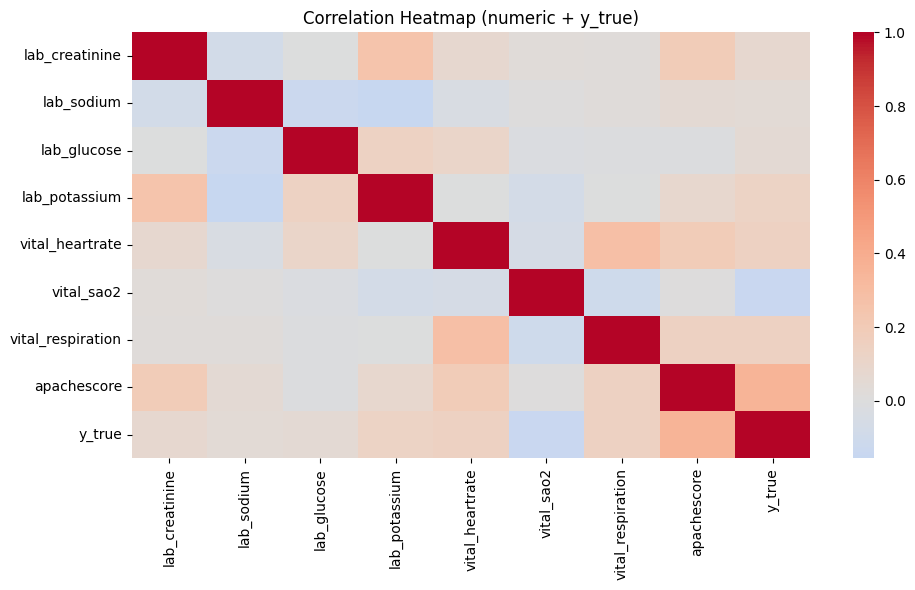


=== Mortality by ethnicity (descriptive) ===


,n,mortality_rate
group,,
Caucasian,2010,0.0861
African American,231,0.0390
Hispanic,115,0.0957
Other/Unknown,83,0.1325
Unknown,39,0.1026
Asian,30,0.1333



=== Mortality by gender (descriptive) ===


,n,mortality_rate
group,,
Male,1508,0.0822
Female,1008,0.0863



=== Mortality by age_group (descriptive) ===


,n,mortality_rate
group,,
over_65,1295,0.1174
45_65,787,0.0661
under_45,434,0.0161



=== Mortality by region (descriptive) ===


,n,mortality_rate
group,,
Midwest,807,0.0719
South,738,0.0854
West,606,0.0825
Unknown,210,0.1048
Northeast,159,0.1195


In [13]:
# =========================================================
# FairnessOps - Canonical Dataset EDA (Colab-ready)
# =========================================================
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

# ----------------------------
# 1) Locate canonical dataset
# ----------------------------

# Option A: if already in /content
# DATA_PATH = Path("/content/canonical_dataset.csv")

# Option B: if in Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = Path("/content/drive/MyDrive/Fairness Ops/runs/canonical_dataset.csv")

# Auto-candidates (edit if needed)
candidates = [
    Path("/content/canonical_dataset.csv"),
    Path("/content/runs/canonical_dataset.csv"),
    Path("/content/drive/MyDrive/Fairness Ops/runs/canonical_dataset.csv"),
    Path("/content/drive/MyDrive/canonical_dataset.csv"),
]

DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "canonical_dataset.csv not found. Update DATA_PATH to your actual file location."
    )

print("Using:", DATA_PATH)

# ----------------------------
# 2) Load dataset
# ----------------------------

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head(5))

# ----------------------------
# 3) Basic schema + missingness
# ----------------------------

print("\nDtypes:")
display(df.dtypes.to_frame("dtype").T)
missing_pct = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
print("\nMissingness (%):")
display(missing_pct.to_frame("missing_pct"))

# ----------------------------
# 4) Label distribution
# ----------------------------

if "y_true" not in df.columns:
    raise ValueError("Expected column 'y_true' not found.")

label_counts = df["y_true"].value_counts(dropna=False).sort_index()
label_pct = (
    (df["y_true"].value_counts(normalize=True, dropna=False) * 100)
    .sort_index()
    .round(2)
)

print("\nLabel counts:")
display(label_counts.to_frame("count"))
print("Label percent:")
display(label_pct.to_frame("pct"))
print(f"Mortality prevalence (y_true=1): {df['y_true'].mean():.3%}")

# ----------------------------
# 5) Protected attribute profiling
# ----------------------------

protected_cols = [
    c
    for c in ["ethnicity", "gender", "age_group", "region", "insurance", "language"]
    if c in df.columns
]

for c in protected_cols:
    print(f"\n=== {c} distribution ===")
    vc = df[c].fillna("Unknown").value_counts(dropna=False)
    display(vc.to_frame("count").head(20))

# ----------------------------
# 6) Numeric feature summary
# ----------------------------

id_and_label = {"patientunitstayid", "hospitalid", "y_true"}
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in id_and_label]

print("\nNumeric modeling columns:")
print(numeric_cols)

if numeric_cols:
    print("\nSummary stats:")
    display(df[numeric_cols].describe().T)

# ----------------------------
# 7) Correlation quick look
# ----------------------------

if len(numeric_cols) >= 2:
    plt.figure(figsize=(10, 6))
    corr = df[numeric_cols + ["y_true"]].corr(numeric_only=True)
    sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
    plt.title("Correlation Heatmap (numeric + y_true)")
    plt.tight_layout()
    plt.show()

# ----------------------------
# 8) Group mortality (descriptive)
# ----------------------------


def mortality_by_group(data, group_col, min_n=20):
    tmp = (
        data.assign(group=data[group_col].astype("object").fillna("Unknown"))
        .groupby("group")
        .agg(n=("y_true", "size"), mortality_rate=("y_true", "mean"))
        .sort_values("n", ascending=False)
    )
    tmp["mortality_rate"] = tmp["mortality_rate"].round(4)
    return tmp[tmp["n"] >= min_n]


for c in [x for x in ["ethnicity", "gender", "age_group", "region"] if x in df.columns]:
    print(f"\n=== Mortality by {c} (descriptive) ===")
    display(mortality_by_group(df, c, min_n=20).head(20))

In [14]:
print(df)

      patientunitstayid  hospitalid  y_true         ethnicity  gender age_group insurance language   region  lab_creatinine  lab_sodium  lab_glucose  \
0                141764          59       0         Caucasian  Female   over_65   Unknown  Unknown  Midwest             NaN         NaN          NaN   
1                141765          59       0         Caucasian  Female   over_65   Unknown  Unknown  Midwest           1.040       139.0         79.0   
2                143870          68       0         Caucasian    Male   over_65   Unknown  Unknown  Midwest           1.015       136.0        131.5   
3                144815          56       0         Caucasian  Female  under_45   Unknown  Unknown  Midwest           0.690       141.0         90.5   
4                145427          68       0         Caucasian    Male     45_65   Unknown  Unknown  Midwest           1.120       139.5        128.5   
...                 ...         ...     ...               ...     ...       ...       ..

In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
  roc_auc_score, average_precision_score,
  confusion_matrix, classification_report
)

In [18]:
DATA_PATH = Path("/content/canonical_dataset.csv")
df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH)
print("Shape:", df.shape)

Loaded: /content/canonical_dataset.csv
Shape: (2520, 17)


In [19]:
# 2) Define target, model features, fairness attrs
label_col = "y_true"
model_feature_cols = [
  "lab_creatinine", "lab_sodium", "lab_glucose", "lab_potassium",
  "vital_heartrate", "vital_sao2", "vital_respiration", "apachescore"
]
# Use only available + meaningful fairness attrs
fairness_cols = [c for c in ["ethnicity", "gender", "age_group", "region"] if c in df.columns]
# Optional: hard-drop attrs that are constant Unknown in your build
df = df.drop(columns=["insurance", "language"], errors="ignore")

In [20]:
# Keep only required cols
required_cols = ["patientunitstayid", "hospitalid", label_col] + fairness_cols + model_feature_cols
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
  raise ValueError(f"Missing required columns: {missing_required}")
work = df[required_cols].copy()

In [21]:
# Ensure label is valid binary
work = work.dropna(subset=[label_col]).copy()
work[label_col] = work[label_col].astype(int)
# Fill fairness attrs with Unknown for safe grouping
for c in fairness_cols:
  work[c] = work[c].astype("object").fillna("Unknown")
X = work[model_feature_cols].copy()
y = work[label_col].copy()


In [22]:
print(model_feature_cols)

['lab_creatinine', 'lab_sodium', 'lab_glucose', 'lab_potassium', 'vital_heartrate', 'vital_sao2', 'vital_respiration', 'apachescore']


In [23]:
print(label_col)

y_true


In [24]:
# 3) Train/test split (stratified), preserve index for fairness slicing
X_tr, X_te, y_tr, y_te, idx_tr, idx_te = train_test_split(
  X, y, work.index,
  test_size=0.25,
  random_state=42,
  stratify=y
)

In [25]:
# 4) Build + fit model
logreg_pipe = Pipeline([
  ("imputer", SimpleImputer(strategy="median")),
  ("model", LogisticRegression(
      max_iter=1000,
      class_weight="balanced",
      solver="liblinear",
      random_state=42
  ))
])

In [26]:
logreg_pipe.fit(X_tr, y_tr)


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42, solver='liblinear'))])

In [27]:
# 5) Predictions
proba_te = logreg_pipe.predict_proba(X_te)[:, 1]
pred_te_05 = (proba_te >= 0.50).astype(int)

In [28]:
# 6) Overall performance
roc = roc_auc_score(y_te, proba_te)
pr = average_precision_score(y_te, proba_te)
cm = confusion_matrix(y_te, pred_te_05)

In [29]:
print("\n=== Logistic Regression Overall Metrics ===")
print(f"ROC-AUC: {roc:.4f}")
print(f"PR-AUC : {pr:.4f}")
print("\nConfusion Matrix @0.50:")
print(cm)
print("\nClassification Report @0.50:")
print(classification_report(y_te, pred_te_05, digits=4))


=== Logistic Regression Overall Metrics ===
ROC-AUC: 0.8363
PR-AUC : 0.5018

Confusion Matrix @0.50:
[[444 133]
 [ 14  39]]

Classification Report @0.50:
              precision    recall  f1-score   support

           0     0.9694    0.7695    0.8580       577
           1     0.2267    0.7358    0.3467        53

    accuracy                         0.7667       630
   macro avg     0.5981    0.7527    0.6023       630
weighted avg     0.9070    0.7667    0.8150       630



In [30]:
# 7) Build fairness-ready prediction frame
pred_df = work.loc[idx_te, ["patientunitstayid", "hospitalid", label_col] + fairness_cols].copy()
pred_df["y_pred_proba"] = proba_te
pred_df["y_pred_label_05"] = pred_te_05
print("\nFairness-ready prediction frame:")
display(pred_df.head())


Fairness-ready prediction frame:


,patientunitstayid,hospitalid,y_true,ethnicity,gender,age_group,region,y_pred_proba,y_pred_label_05
1924,2726655,407,0,Hispanic,Male,under_45,West,0.067695,0
1854,2677807,387,0,Caucasian,Male,over_65,West,0.365565,0
1229,1569571,249,0,Caucasian,Female,over_65,Midwest,0.275140,0
609,752830,165,0,African American,Female,45_65,West,0.122211,0
135,214519,66,0,Caucasian,Female,45_65,Midwest,0.187792,0


In [35]:
# Pick threshold: using 0.40 for safety-first recall
chosen_threshold = 0.40
y_pred_label_chosen = (proba_te >= chosen_threshold).astype(int)

# Recreate pred_df with the chosen threshold
pred_df_final = work.loc[idx_te, ["patientunitstayid", label_col] + fairness_cols].copy()
pred_df_final["y_pred_proba"] = proba_te
pred_df_final["y_pred_label"] = y_pred_label_chosen

print("Fairness-ready prediction frame with chosen threshold:")
display(pred_df_final.head())

Fairness-ready prediction frame with chosen threshold:


,patientunitstayid,y_true,ethnicity,gender,age_group,region,y_pred_proba,y_pred_label
1924,2726655,0,Hispanic,Male,under_45,West,0.067695,0
1854,2677807,0,Caucasian,Male,over_65,West,0.365565,0
1229,1569571,0,Caucasian,Female,over_65,Midwest,0.275140,0
609,752830,0,African American,Female,45_65,West,0.122211,0
135,214519,0,Caucasian,Female,45_65,Midwest,0.187792,0


In [36]:
import json

# Freeze metadata
metadata = {
    "model_type": "Logistic Regression",
    "features": model_feature_cols,
    "target_label": label_col,
    "protected_attributes": fairness_cols,
    "training_test_split_ratio": 0.25,
    "training_test_split_random_state": 42,
    "prediction_threshold": chosen_threshold
}

print("Metadata created:")
display(metadata)

Metadata created:


{'model_type': 'Logistic Regression',
 'features': ['lab_creatinine',
  'lab_sodium',
  'lab_glucose',
  'lab_potassium',
  'vital_heartrate',
  'vital_sao2',
  'vital_respiration',
  'apachescore'],
 'target_label': 'y_true',
 'protected_attributes': ['ethnicity', 'gender', 'age_group', 'region'],
 'training_test_split_ratio': 0.25,
 'training_test_split_random_state': 42,
 'prediction_threshold': 0.4}

In [37]:
out_dir = Path("/content/runs")
out_dir.mkdir(parents=True, exist_ok=True)

# Export updated prediction artifact
pred_df_final.to_csv(out_dir / "logreg_test_predictions_rethresholded.csv", index=False)
print("Saved updated prediction artifact:", out_dir / "logreg_test_predictions_rethresholded.csv")

# Export metadata
with open(out_dir / "logreg_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print("Saved model metadata:", out_dir / "logreg_model_metadata.json")

Saved updated prediction artifact: /content/runs/logreg_test_predictions_rethresholded.csv
Saved model metadata: /content/runs/logreg_model_metadata.json


In [33]:
 out = Path("/content/runs")
 out.mkdir(parents=True, exist_ok=True)
 pred_df.to_csv(out / "logreg_test_predictions.csv", index=False)
 print("Saved:", out / "logreg_test_predictions.csv")


Saved: /content/runs/logreg_test_predictions.csv


In [34]:
for t in [0.30, 0.40, 0.50, 0.60]:
    p = (proba_te >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te, p).ravel()
    recall    = tp / (tp + fn) if (tp + fn) else np.nan
    precision = tp / (tp + fp) if (tp + fp) else np.nan
    print(f"thr={t:.2f} | precision={precision:.3f} recall={recall:.3f} | tp={tp} fp={fp} fn={fn} tn={tn}")

thr=0.30 | precision=0.126 recall=0.943 | tp=50 fp=347 fn=3 tn=230
thr=0.40 | precision=0.167 recall=0.849 | tp=45 fp=225 fn=8 tn=352
thr=0.50 | precision=0.227 recall=0.736 | tp=39 fp=133 fn=14 tn=444
thr=0.60 | precision=0.307 recall=0.585 | tp=31 fp=70 fn=22 tn=507
